<a href="https://colab.research.google.com/github/Insight-Syndicate/DSPL_GCW/blob/main/Model_building.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Import Necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Data Scaling**

## **Test**

In [2]:
#Access the dataset "clean_test"
clean_test = pd.read_csv("clean_test.csv")

In [3]:
clean_test

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,outlet_city_encoded
0,33574,Batticaloa,2686.50,3582.00,12537.00,1
1,10089,Batticaloa,1717.56,2576.34,9446.58,1
2,38329,Batticaloa,854.04,1242.24,5201.88,1
3,11376,Batticaloa,1638.12,2320.67,9282.68,1
4,12410,Batticaloa,1039.09,1518.67,5435.24,1
...,...,...,...,...,...,...
40744,33698,Wattala,3916.48,4161.26,3916.48,21
40745,4185,Wattala,3191.92,3004.16,3098.04,21
40746,28664,Wattala,3838.60,3951.50,3700.00,21
40747,11874,Wattala,4313.76,4183.04,4313.76,21


We are using the robust scaller since our data is skewed and luxury sales has outliers. Since this technique scales using the median and IQR it is best suited to deal with the skewness and the extreme values.

In [4]:
from sklearn.preprocessing import RobustScaler
# Identify numerical columns
numerical_columns = ['luxury_sales', 'fresh_sales', 'dry_sales']

# Initialize RobustScaler
DSPL_scaler = RobustScaler()

# Fit on training numerical data and transform both train & test
clean_test[numerical_columns] = DSPL_scaler.fit_transform(clean_test[numerical_columns])
clean_test

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,outlet_city_encoded
0,33574,Batticaloa,0.857034,0.041937,1.631090,1
1,10089,Batticaloa,-0.003695,-0.156121,1.057081,1
2,38329,Batticaloa,-0.770778,-0.418864,0.268678,1
3,11376,Batticaloa,-0.074264,-0.206474,1.026639,1
4,12410,Batticaloa,-0.606394,-0.364423,0.312022,1
...,...,...,...,...,...,...
40744,33698,Wattala,1.949650,0.156019,0.029930,21
40745,4185,Wattala,1.306009,-0.071865,-0.122086,21
40746,28664,Wattala,1.880468,0.114708,-0.010279,21
40747,11874,Wattala,2.302562,0.160308,0.103720,21


## **Train**

In [5]:
#Access the dataset "clean_train"
clean_train = pd.read_csv("clean_train.csv")

In [6]:
clean_train

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_catgeory,outlet_city_encoded
0,10493832.0,Kelaniya,1209.60,756.00,5292.00,4,11
1,10178643.0,Moratuwa,1590.12,1060.08,6007.12,1,13
2,10513916.0,Wattala,2288.88,1481.04,9155.52,4,19
3,10334589.0,Wattala,2274.94,1739.66,9099.76,4,19
4,10458365.0,Kelaniya,2345.49,2069.55,9243.99,4,11
...,...,...,...,...,...,...,...
774140,10197979.0,Gampaha,3893.40,3893.40,3448.44,3,4
774141,10494575.0,Katunayake,6095.86,5557.99,6275.15,3,10
774142,10565682.0,Colombo,5121.42,4820.16,4669.53,3,1
774143,10351977.0,Kandy,6311.76,6311.76,5940.48,3,9


We are using the robust scaller since our data is skewed and luxury sales has outliers. Since this technique scales using the median and IQR it is best suited to deal with the skewness and the extreme values.

In [7]:
from sklearn.preprocessing import RobustScaler
# Identify numerical columns
numerical_columns = ['luxury_sales', 'fresh_sales', 'dry_sales']

# Initialize RobustScaler
DSPL_scaler = RobustScaler()

# Fit on training numerical data and transform both train & test
clean_train[numerical_columns] = DSPL_scaler.fit_transform(clean_train[numerical_columns])
clean_train

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_catgeory,outlet_city_encoded
0,10493832.0,Kelaniya,-0.449457,-0.514864,0.291089,4,11
1,10178643.0,Moratuwa,-0.111244,-0.454663,0.424165,1,13
2,10513916.0,Wattala,0.509826,-0.371322,1.010049,4,19
3,10334589.0,Wattala,0.497436,-0.320120,0.999672,4,19
4,10458365.0,Kelaniya,0.560142,-0.254809,1.026512,4,11
...,...,...,...,...,...,...,...
774140,10197979.0,Gampaha,1.935952,0.106275,-0.051979,3,4
774141,10494575.0,Katunayake,3.893537,0.435829,0.474042,3,10
774142,10565682.0,Colombo,3.027438,0.289754,0.175253,3,1
774143,10351977.0,Kandy,4.085433,0.585060,0.411764,3,9


# Logistic Regression

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

In [9]:
# Define X and y variables
X = clean_train[['luxury_sales', 'fresh_sales', 'dry_sales', 'outlet_city_encoded']]
y = clean_train['cluster_catgeory']

In [10]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# Initialize and train Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, solver='saga', random_state=42)
log_reg_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='saga')

In [12]:
# Predict using test data
y_pred = log_reg_model.predict(X_test)

In [13]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"R2: {r2_score(y_test, y_pred):.4f}")

Accuracy: 0.9628
MSE: 0.1796
R2: 0.9487


[[37879     1     0   157     0     1]
 [    2 30707     3     2     3   134]
 [    1     0  7366     2  2371     1]
 [  150     0     3 34249     1     1]
 [    0     0  2771     3  4984     1]
 [    0   137     3     3     2 33891]]


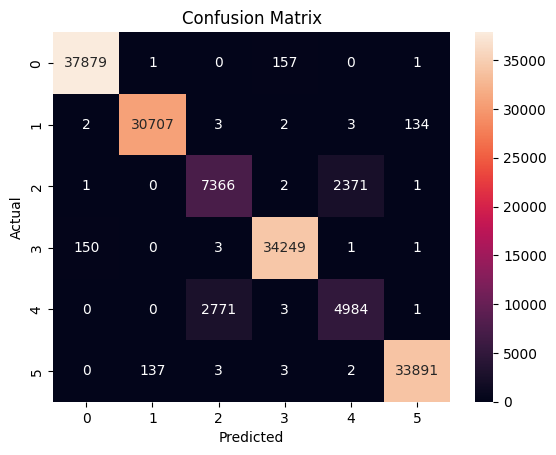

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [15]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00     38038
           2       1.00      1.00      1.00     30851
           3       0.73      0.76      0.74      9741
           4       1.00      1.00      1.00     34404
           5       0.68      0.64      0.66      7759
           6       1.00      1.00      1.00     34036

    accuracy                           0.96    154829
   macro avg       0.90      0.90      0.90    154829
weighted avg       0.96      0.96      0.96    154829



#KNN Model

In [16]:
#Importing relevant libraries
from sklearn.neighbors import KNeighborsClassifier

In [17]:
#X, Y split
x = clean_train[['luxury_sales','fresh_sales','dry_sales','outlet_city_encoded']]
y = clean_train['cluster_catgeory']

In [18]:
# test, train split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

To optimize KNN model we need to find the n_neighbours and this is done by making use of the gridsearchCV system.

In [20]:
from sklearn.model_selection import GridSearchCV
#Define the parameter grid for n_neighbors
param_grid = {'n_neighbors': list(range(1, 10))}

#Create and fit the GridSearchCV object
grid = GridSearchCV(KNeighborsClassifier(algorithm='auto'), param_grid, cv=10, scoring='accuracy', n_jobs=-1)
grid.fit(x_train, y_train)

#Get the best n_neighbors value
best_k = grid.best_params_['n_neighbors']
print(f"Best k value: {best_k}")

Best k value: 7


In [21]:
# Initialize KNN classifier
knn_model = KNeighborsClassifier(n_neighbors=7)

# Train the classifier
knn_model.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=7)

In [22]:
# Assuming you have y_test (true labels) and y_pred (predicted labels) from your KNN model
MSE = mean_squared_error(y_test, y_pred)
r2_ = r2_score(y_test, y_pred)
Acs = accuracy_score(y_test, y_pred)

print(f"MSE: {MSE}")
print(f"R2: {r2_}")
print(f"Accuracy: {Acs}")

MSE: 0.17955938486975953
R2: 0.9486714236376396
Accuracy: 0.9628428782721583


[[37879     1     0   157     0     1]
 [    2 30707     3     2     3   134]
 [    1     0  7366     2  2371     1]
 [  150     0     3 34249     1     1]
 [    0     0  2771     3  4984     1]
 [    0   137     3     3     2 33891]]


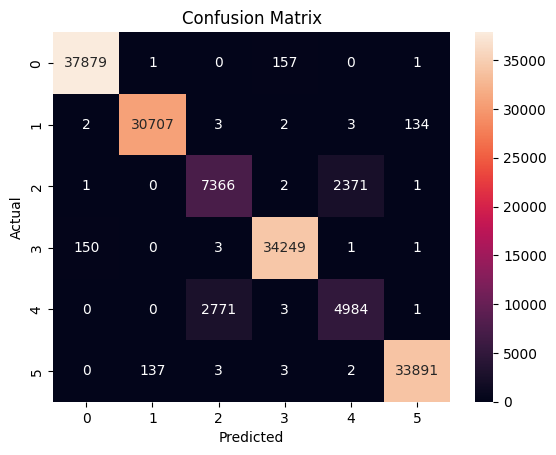

In [23]:
#Create a confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [24]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00     38038
           2       1.00      1.00      1.00     30851
           3       0.73      0.76      0.74      9741
           4       1.00      1.00      1.00     34404
           5       0.68      0.64      0.66      7759
           6       1.00      1.00      1.00     34036

    accuracy                           0.96    154829
   macro avg       0.90      0.90      0.90    154829
weighted avg       0.96      0.96      0.96    154829



Distribution of Predicted Clusters:
{1: 38035, 2: 30844, 3: 9750, 4: 34411, 5: 7759, 6: 34030}


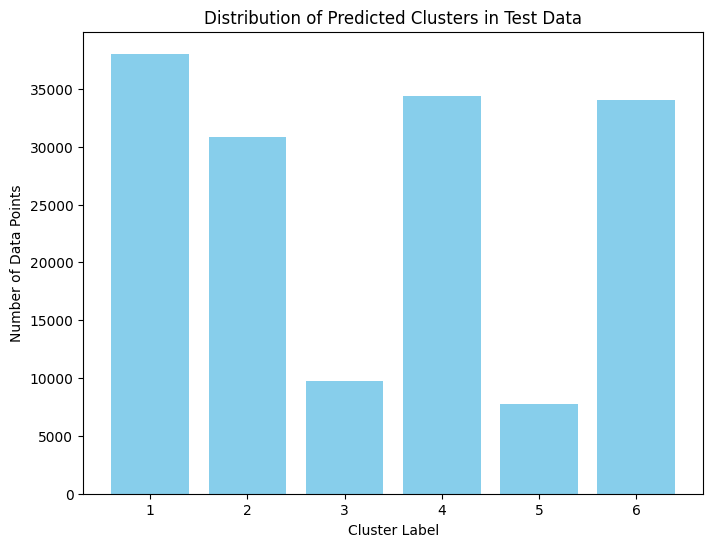

In [25]:
# Predict cluster labels for the test data
y_predict = knn_model.predict(X_test)

# Analyze the distribution of predicted clusters
unique, counts = np.unique(y_predict, return_counts=True)
cluster_dist = dict(zip(unique, counts))

print("Distribution of Predicted Clusters:")
print(cluster_dist)

# Visualize the distribution
plt.figure(figsize=(8, 6))
plt.bar(cluster_dist.keys(), cluster_dist.values(), color='skyblue')
plt.xlabel("Cluster Label")
plt.ylabel("Number of Data Points")
plt.title("Distribution of Predicted Clusters in Test Data")
plt.show()

#Decsion Tree Model

In [26]:
# Define X and y variables
x = clean_train[['luxury_sales', 'fresh_sales', 'dry_sales', 'outlet_city_encoded']]
y = clean_train['cluster_catgeory']

In [27]:
x

,luxury_sales,fresh_sales,dry_sales,outlet_city_encoded
0,-0.449457,-0.514864,0.291089,11
1,-0.111244,-0.454663,0.424165,13
2,0.509826,-0.371322,1.010049,19
3,0.497436,-0.320120,0.999672,19
4,0.560142,-0.254809,1.026512,11
...,...,...,...,...
774140,1.935952,0.106275,-0.051979,4
774141,3.893537,0.435829,0.474042,10
774142,3.027438,0.289754,0.175253,1
774143,4.085433,0.585060,0.411764,9


In [28]:
y

,cluster_catgeory
0,4
1,1
2,4
3,4
4,4
...,...
774140,3
774141,3
774142,3
774143,3


In [29]:
# test, train split
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.25, random_state=1, stratify=y)

In [30]:
#Train the decison tree model
from sklearn.tree import DecisionTreeClassifier
dt_d = DecisionTreeClassifier()
dt_d.fit(X_train, Y_train)

DecisionTreeClassifier()

In [31]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"R2: {r2_score(y_test, y_pred):.4f}")

Accuracy: 0.9628
MSE: 0.1796
R2: 0.9487


[[37879     1     0   157     0     1]
 [    2 30707     3     2     3   134]
 [    1     0  7366     2  2371     1]
 [  150     0     3 34249     1     1]
 [    0     0  2771     3  4984     1]
 [    0   137     3     3     2 33891]]


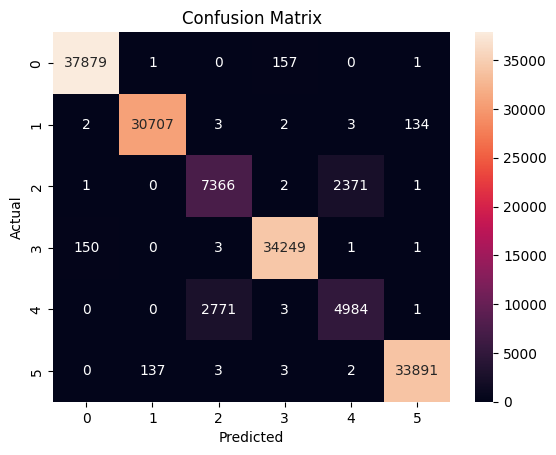

In [32]:
#Create a confusion matrix to analyse the performance of the DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [33]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00     38038
           2       1.00      1.00      1.00     30851
           3       0.73      0.76      0.74      9741
           4       1.00      1.00      1.00     34404
           5       0.68      0.64      0.66      7759
           6       1.00      1.00      1.00     34036

    accuracy                           0.96    154829
   macro avg       0.90      0.90      0.90    154829
weighted avg       0.96      0.96      0.96    154829



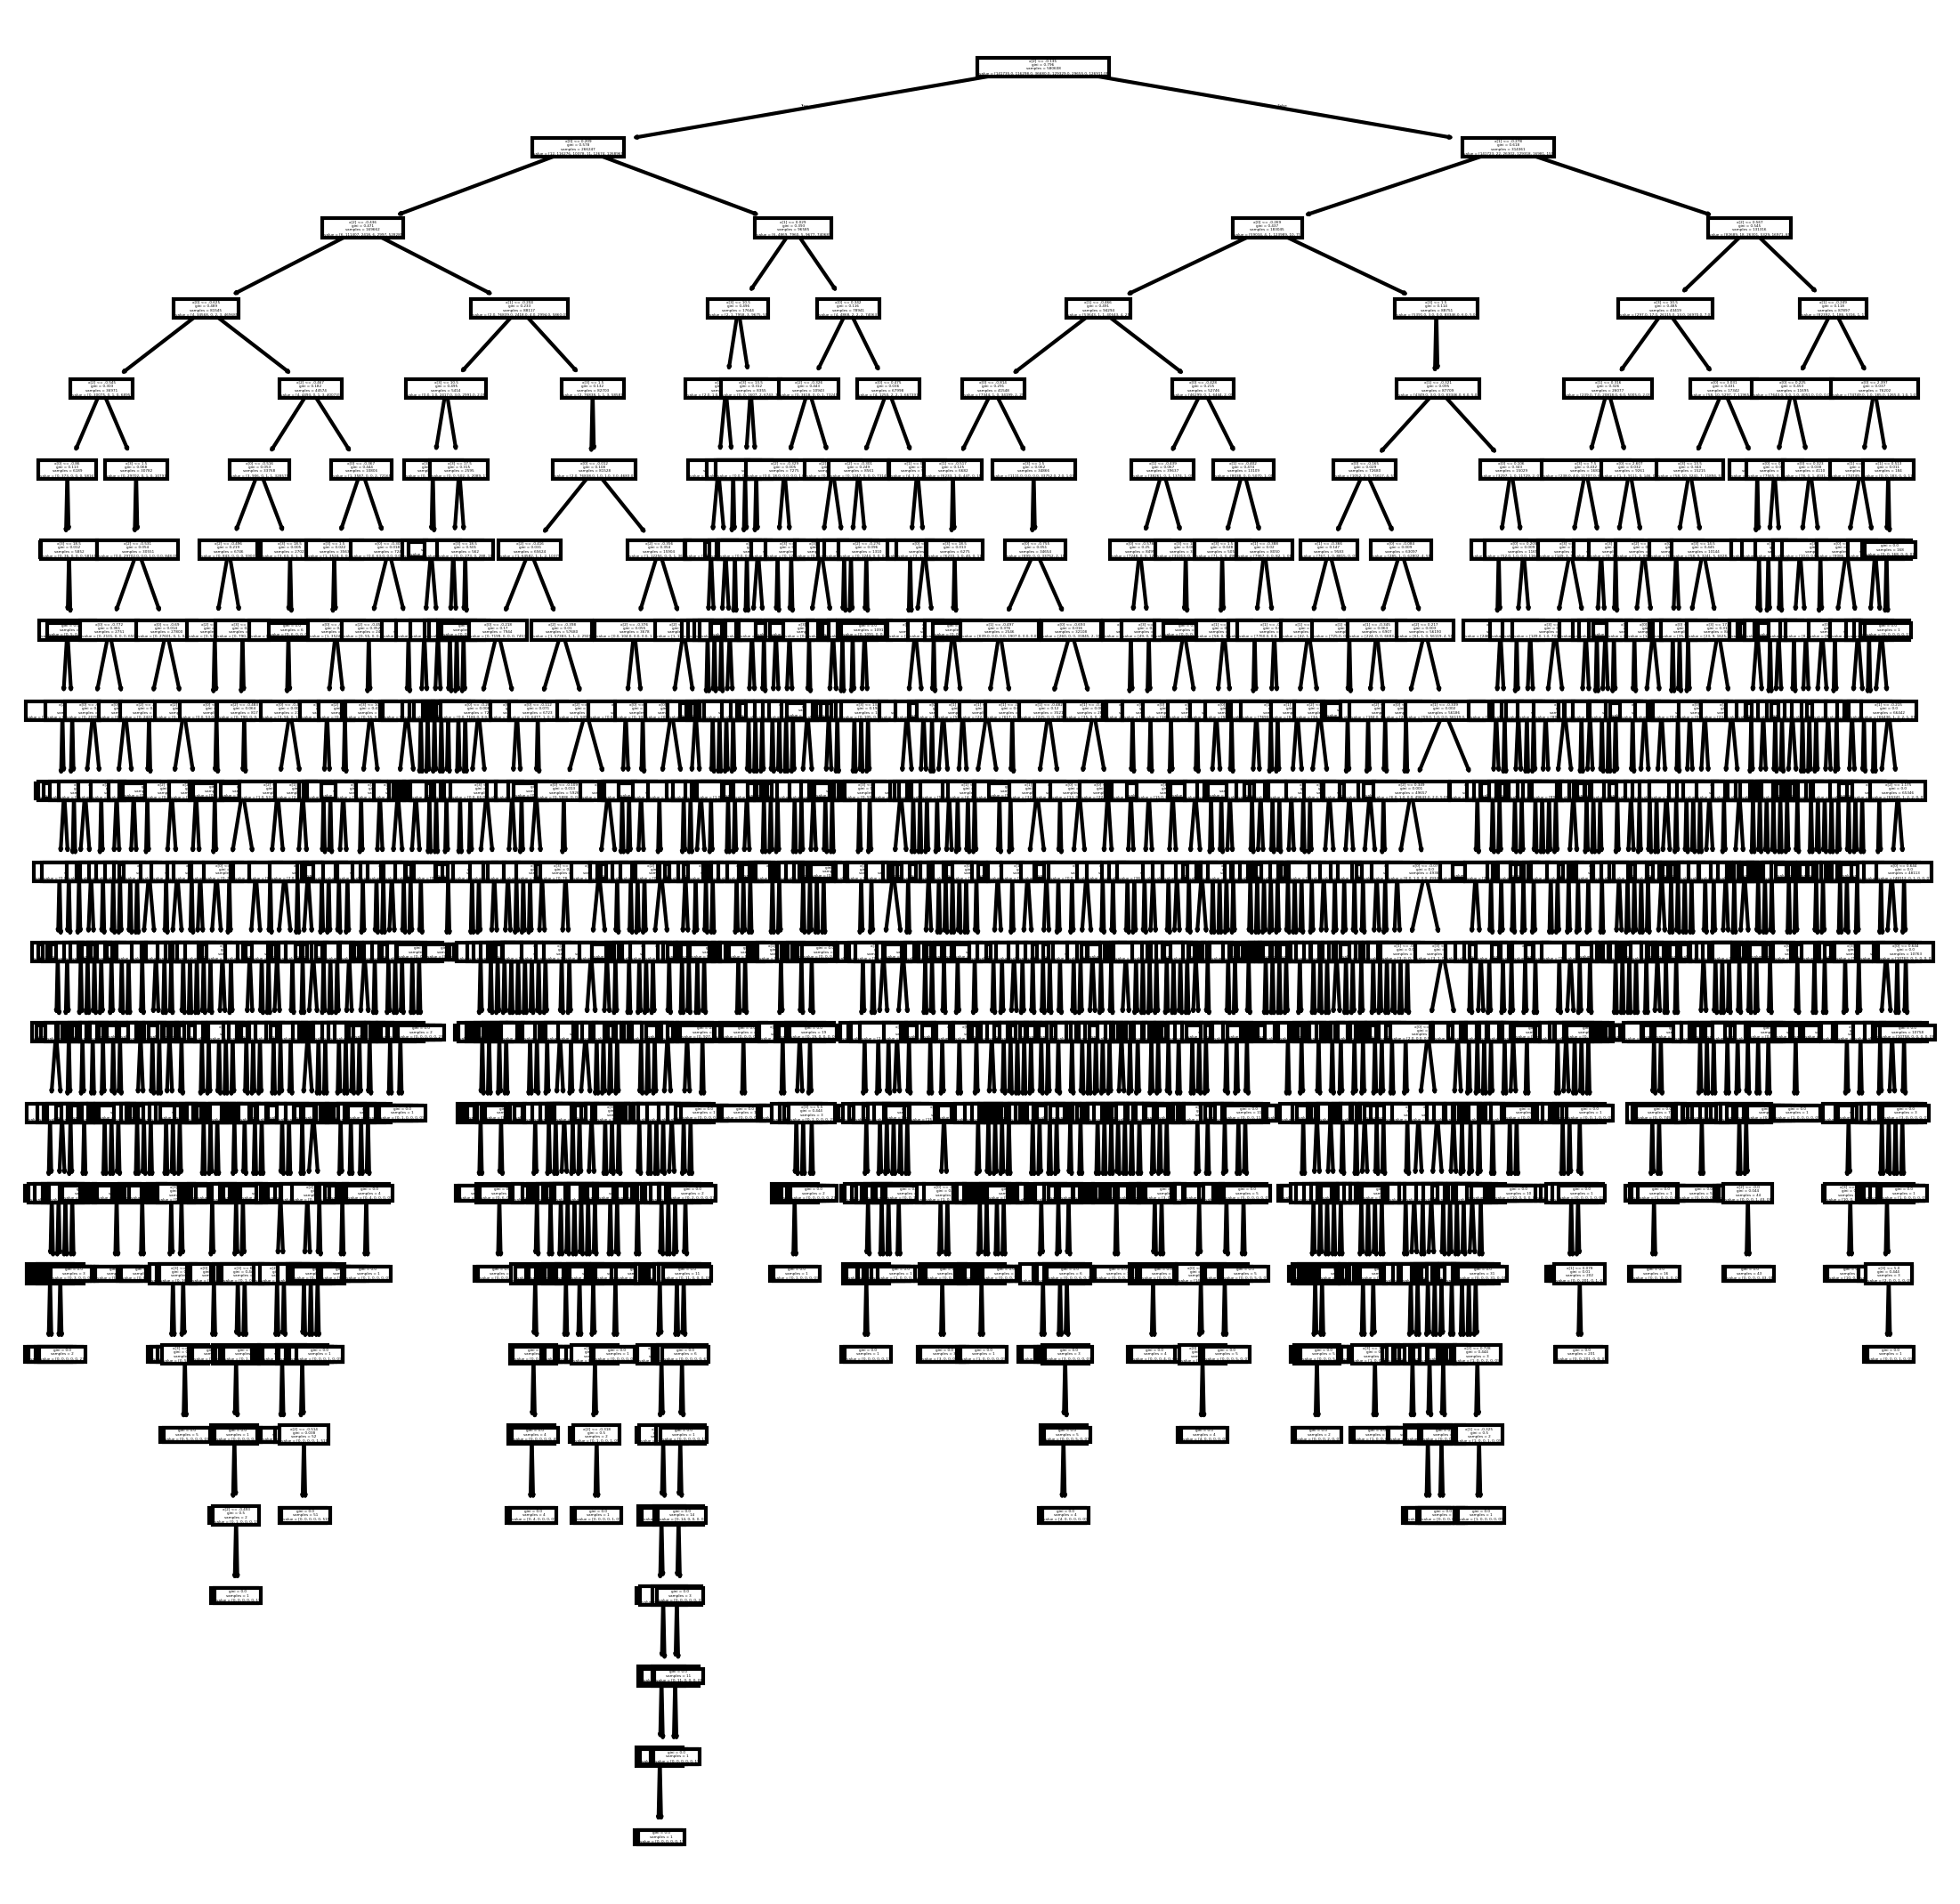

In [34]:
#Plotting the decsion tree
from sklearn import tree
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 9), dpi=300)
tree.plot_tree(dt_d)
plt.show()

# Random Forest Model

In [35]:
# Checking for feature balance in the train data
clean_train['cluster_catgeory'].value_counts()

,count
cluster_catgeory,
1,188980
4,172439
6,169215
2,155064
3,48907
5,39540


In [36]:
# Importing code bloxks from the scikit learn library
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, r2_score

Since customer Id has no prediction value and is only a unique identifier it is not included in the features in the x dataframe since including it migh lead to over fitting the model.

In [37]:
# Difine X and Y variables
x = clean_train[['luxury_sales','fresh_sales','dry_sales','outlet_city_encoded']]
y = clean_train['cluster_catgeory']

In [38]:
# test, train split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [39]:
# creating the randome forest classifier (rfc) model
rfc_model = RandomForestClassifier(n_estimators=25, random_state=42)

n_estimators is the hyperparameter in random forest which tells the number of decision trees in the forest. Higher n_estimators mean higher accuracy but also higher computational cost and time. Therefore, 25 has been settled on as the balance between accuracy, computational cost as futher increase in this hyper parameter would only provide dimnishing returns.

In [40]:
# Train the model
rfc_model.fit(x_train, y_train)

RandomForestClassifier(n_estimators=25, random_state=42)

In [41]:
# Predict using the x_test data
y_pred = rfc_model.predict(x_test)

In [42]:
# Evaluate the model
MSE = mean_squared_error(y_test, y_pred)
r2_= r2_score(y_test, y_pred)
Acs = accuracy_score(y_test, y_pred)

print(f"MSE:{MSE}")
print(f"R2:{r2_}")
print(f"Accuracy:{Acs}")

MSE:0.006187471339348572
R2:0.9982312587261198
Accuracy:0.9992959975198444


In [43]:
# confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[38013,     1,     0,    23,     0,     1],
       [    1, 30834,     3,     4,     1,     8],
       [    0,     0,  9739,     0,     1,     1],
       [   19,     0,     1, 34381,     2,     1],
       [    0,     0,    13,     3,  7742,     1],
       [    0,    17,     4,     3,     1, 34011]])

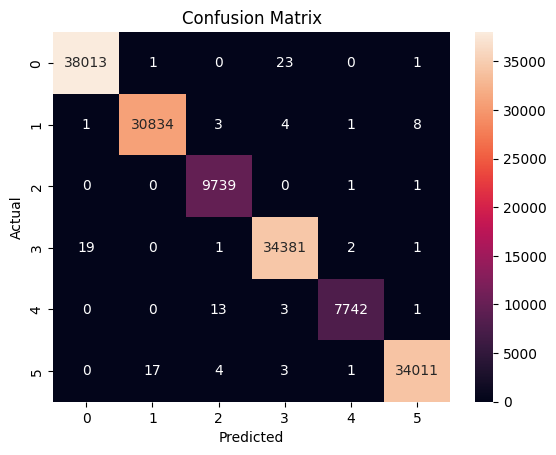

In [44]:
# heatmap of contribution matrix
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

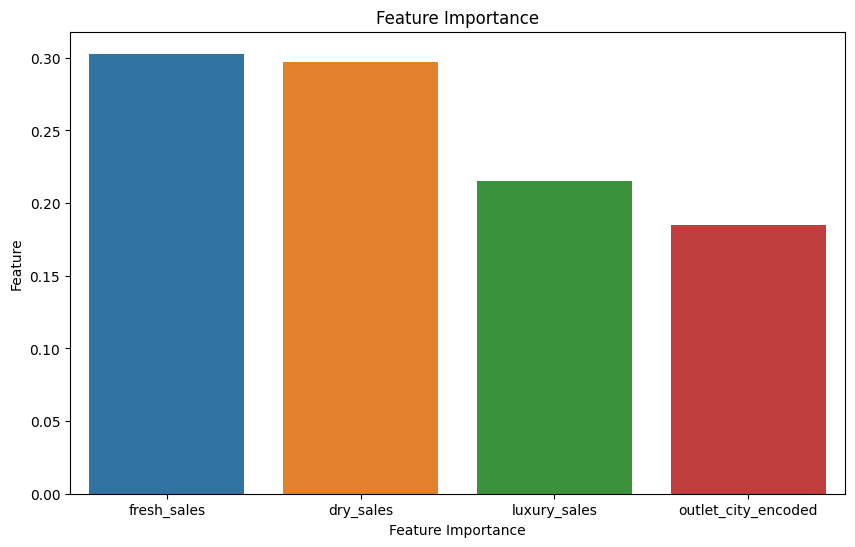

In [45]:
# importance of each feature
feature_importance = rfc_model.feature_importances_
features = x_train.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# plot
plt.figure(figsize=(10, 6))
sns.barplot(y='Importance', x='Feature', data=importance_df, hue='Feature')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()

In [46]:
# classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00     38038
           2       1.00      1.00      1.00     30851
           3       1.00      1.00      1.00      9741
           4       1.00      1.00      1.00     34404
           5       1.00      1.00      1.00      7759
           6       1.00      1.00      1.00     34036

    accuracy                           1.00    154829
   macro avg       1.00      1.00      1.00    154829
weighted avg       1.00      1.00      1.00    154829



# Gradient Boosting Model

In [47]:
# Checking for feature balance in the train data
clean_train['cluster_catgeory'].value_counts()

,count
cluster_catgeory,
1,188980
4,172439
6,169215
2,155064
3,48907
5,39540


In [48]:
# Importing code bloxks from the scikit learn library
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [49]:
# Difine X and Y variables
x = clean_train[['luxury_sales','fresh_sales','dry_sales','outlet_city_encoded']]
y = clean_train['cluster_catgeory']

In [50]:
# test, train split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [51]:
# create the Gradient Boosting Classificatio (gbc) model
gbc_model = GradientBoostingClassifier(n_estimators=25, random_state=42)

In [52]:
# Train the model
gbc_model.fit(x_train, y_train)

GradientBoostingClassifier(n_estimators=25, random_state=42)

In [53]:
# predict using the model
y_pred = gbc_model.predict(x_test)

In [54]:
# Evaluate the model
MSE = mean_squared_error(y_test, y_pred)
r2_= r2_score(y_test, y_pred)
Acs = accuracy_score(y_test, y_pred)

print(f"MSE:{MSE}")
print(f"R2:{r2_}")
print(f"Accuracy:{Acs}")

MSE:0.13923102261204295
R2:0.9601996287671881
Accuracy:0.9766129084344665


[[37748     1     0   288     0     1]
 [    5 30729     3     2     2   110]
 [    1     0  8382     5  1352     1]
 [  212     0     2 34188     1     1]
 [    2     0  1350     3  6403     1]
 [    0   271     2     3     2 33758]]


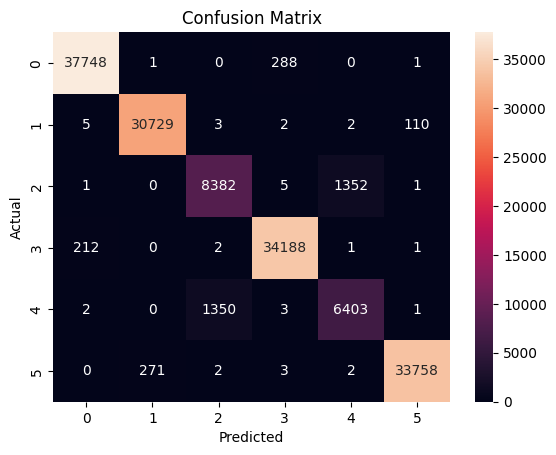

In [55]:
# confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

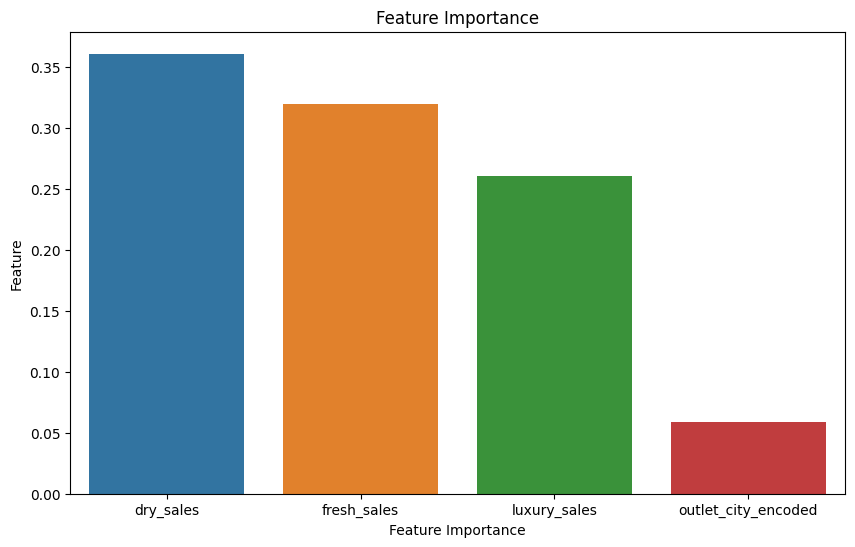

In [56]:
# importance of each feature
feature_importance = gbc_model.feature_importances_
features = x_train.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# plot
plt.figure(figsize=(10, 6))
sns.barplot(y='Importance', x='Feature', data=importance_df, hue='Feature')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()

In [57]:
# classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.99      0.99      0.99     38038
           2       0.99      1.00      0.99     30851
           3       0.86      0.86      0.86      9741
           4       0.99      0.99      0.99     34404
           5       0.83      0.83      0.83      7759
           6       1.00      0.99      0.99     34036

    accuracy                           0.98    154829
   macro avg       0.94      0.94      0.94    154829
weighted avg       0.98      0.98      0.98    154829

